<a href="https://www.kaggle.com/code/emmanuelniyioriolowo/5-machine-learnig-models?scriptVersionId=285027373" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Imports

In [1]:
import numpy as np
import pandas as pd 
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

!pip install shap

/kaggle/input/4-classical-models/metrics_table.csv
/kaggle/input/4-classical-models/__results__.html
/kaggle/input/4-classical-models/lb_ets_resid.csv
/kaggle/input/4-classical-models/__notebook__.ipynb
/kaggle/input/4-classical-models/__output__.json
/kaggle/input/4-classical-models/lb_sarima_resid.csv
/kaggle/input/4-classical-models/custom.css
/kaggle/input/4-classical-models/__results___files/__results___13_3.png
/kaggle/input/4-classical-models/__results___files/__results___16_2.png
/kaggle/input/4-classical-models/__results___files/__results___13_2.png
/kaggle/input/4-classical-models/__results___files/__results___16_3.png
/kaggle/input/4-classical-models/__results___files/__results___13_1.png
/kaggle/input/4-classical-models/__results___files/__results___16_1.png
/kaggle/input/ncdc-lassa-fever-timeseries-20202025/lassa_fever_timeseries_minimal.csv
/kaggle/input/ncdc-lassa-fever-timeseries-20202025/lassa_fever_timeseries_full.csv


# Functions

In [2]:
# Mean Absolute Error (MAE)
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# Root Mean Squared Error (RMSE)
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

# Mean Absolute Percentage Error (MAPE)
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0  # avoid division by zero
    return (np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

# Function to calculate all three metrics
def calculate_evaluation_metrics(y_true, y_pred):
    metrics = []
    metrics.append(mae(y_true, y_pred).round(2))
    metrics.append(rmse(y_true, y_pred).round(2))
    metrics.append(mape(y_true, y_pred).round(2))
    return metrics


# plot graph 
def plot_forecasts(forecast, title):
    """Function to plot the forecasts"""
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train.index, y=train['confirmed_cases'], name="Train", line=dict(color='#1f77b4')))
    fig.add_trace(go.Scatter(x=test.index, y=test['confirmed_cases'], name="Test", line=dict(color='#2ca02c')))
    fig.add_trace(go.Scatter(x=test.index, y=forecast, name="Forecast", line=dict(color='#ff0000')))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                     width=650, title_x=0.5, height=400, xaxis_title='Date',
                     yaxis_title='Confirmed Cases')
    return fig.show()


metrics_table = pd.read_csv('/kaggle/input/4-classical-models/metrics_table.csv')

# Data Extraction and EDA

In [3]:
# read data into a dataframe
df = pd.read_csv('/kaggle/input/ncdc-lassa-fever-timeseries-20202025/lassa_fever_timeseries_minimal.csv')

# construct series dataframe
ts_data = df[['week_end_date', 'epi_week', 'confirmed_cases']].copy()
ts_data.columns = ['date', 'epi_week', 'confirmed_cases']

# Ensure datetime index
ts_data['date'] = pd.to_datetime(ts_data['date'])
ts_data = ts_data.set_index('date')
ts_data = ts_data.asfreq('W') # set frequency to weekly
ts_data

,epi_week,confirmed_cases
date,,
2020-01-05,1,18
2020-01-12,2,64
2020-01-19,3,81
2020-01-26,4,95
2020-02-02,5,104
...,...,...
2025-10-19,42,9
2025-10-26,43,11
2025-11-02,44,12


In [4]:
# Some basic EDA
print(ts_data.dtypes)
print(ts_data.isnull().sum())
print(ts_data.describe())

epi_week           int64
confirmed_cases    int64
dtype: object
epi_week           0
confirmed_cases    0
dtype: int64
         epi_week  confirmed_cases
count  307.000000       307.000000
mean    26.136808        20.540717
std     14.879500        25.897753
min      1.000000         0.000000
25%     13.000000         6.000000
50%     26.000000        10.000000
75%     39.000000        21.000000
max     53.000000       137.000000


In [5]:
# create and display plot 
fig =  px.line(ts_data, x=ts_data.index, y="confirmed_cases",
        title="Weekly Lassa Fever Cases (2020–2025)")
fig.show()

In [6]:
# create time lags 
# ts_data['lag_1'] = ts_data['confirmed_cases'].shift(1)
# ts_data['lag_2'] = ts_data['confirmed_cases'].shift(2)
# ts_data['lag_3'] = ts_data['confirmed_cases'].shift(3)
# ts_data['lag_4'] = ts_data['confirmed_cases'].shift(4)

In [7]:
# generate 52 lags
for i in range(1, 53):
    ts_data[f'lag_{i}'] = ts_data['confirmed_cases'].shift(i)

# rolling windows 
ts_data['roll_mean_4'] = ts_data['confirmed_cases'].rolling(4).mean()
ts_data['roll_mean_12'] = ts_data['confirmed_cases'].rolling(12).mean()
ts_data['roll_mean_52'] = ts_data['confirmed_cases'].rolling(52).mean()

In [8]:
# drop missing rows
ts_data = ts_data.dropna()

# Train Test Split

In [9]:
# Train Test Split
train = ts_data.iloc[:-int(len(ts_data)*0.2)].copy()
test = ts_data.iloc[-int(len(ts_data)*0.2):].copy()

# XGB Regression

In [10]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
)

X_train = train.drop('confirmed_cases', axis=1)
y_train = train['confirmed_cases']

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [11]:
X_test = test.drop('confirmed_cases', axis=1)
y_pred = xgb_model.predict(X_test)
y_test = test['confirmed_cases']

In [12]:
# Plot the forecasts
plot_forecasts(y_pred, 'XGB (52 lags + rolling) Forecast')

# Calculate metrics and add to results dataframe
metrics_list = ['XGB (52 lags + rolling)'] + calculate_evaluation_metrics(test['confirmed_cases'], y_pred)
metrics_table.loc[len(metrics_table)] = metrics_list

In [13]:
metrics_table.to_csv('metrics_table.csv', index=False)
metrics_table

,Model,MAE,RMSE,MAPE
0,Naive,16.33,26.37,60.30
1,Average,16.20,20.94,129.03
2,Drift,17.69,27.12,69.84
3,Seasonal Naive,8.74,15.53,49.24
4,Seasonal Mean,7.91,12.25,44.11
5,ETS,8.06,12.79,43.90
6,SARIMA,7.64,12.45,44.46
7,XGB (52 lags + rolling),5.90,8.36,33.28


# Explainability 

<Figure size 800x600 with 0 Axes>

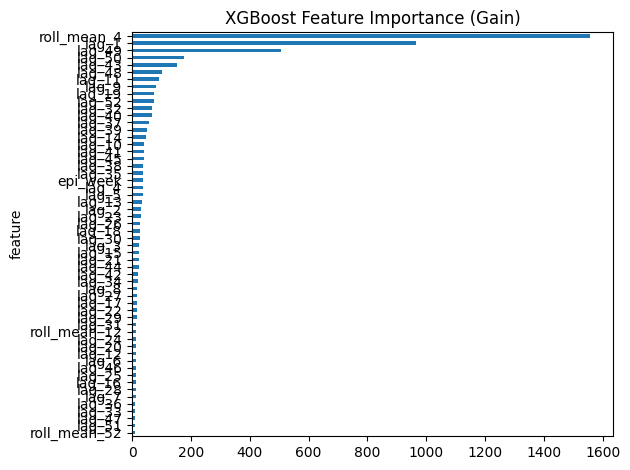

<Figure size 800x600 with 0 Axes>

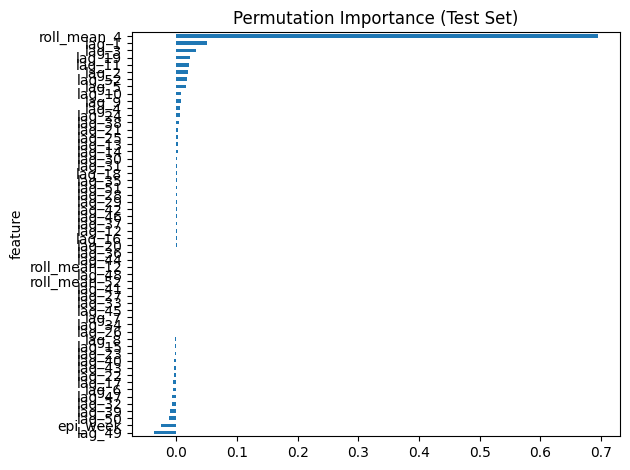

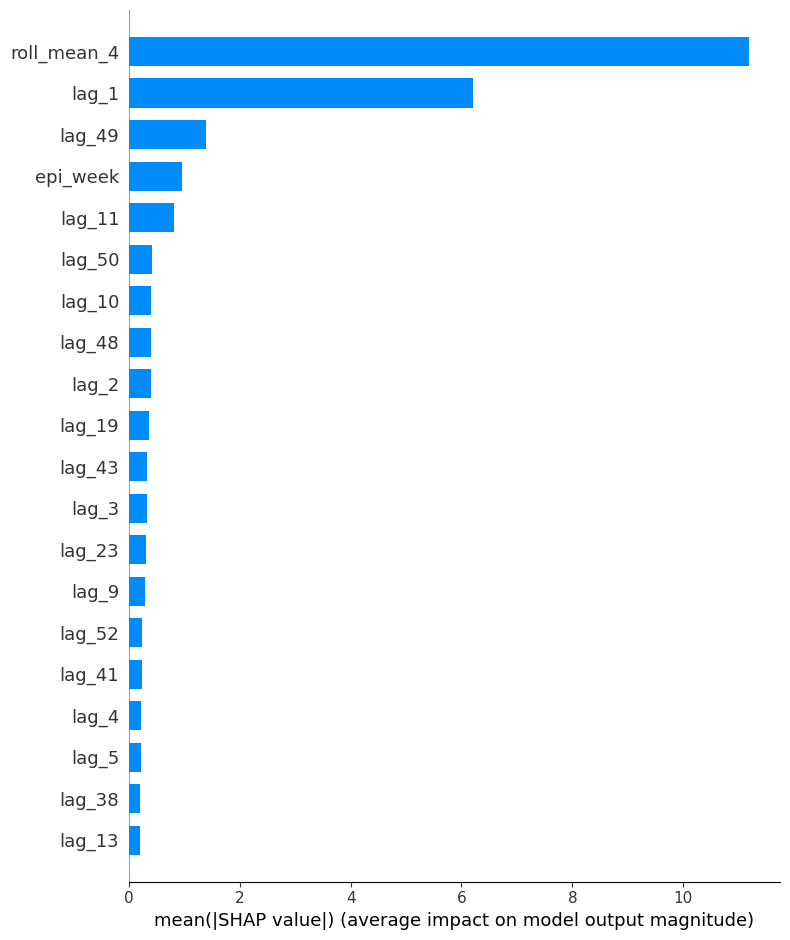

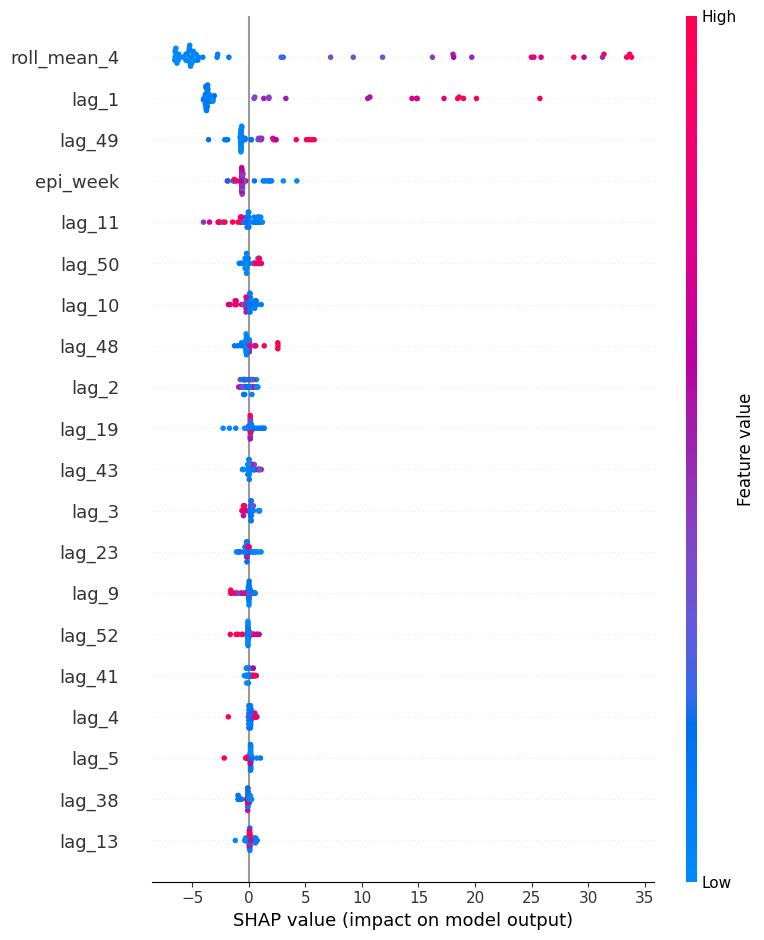

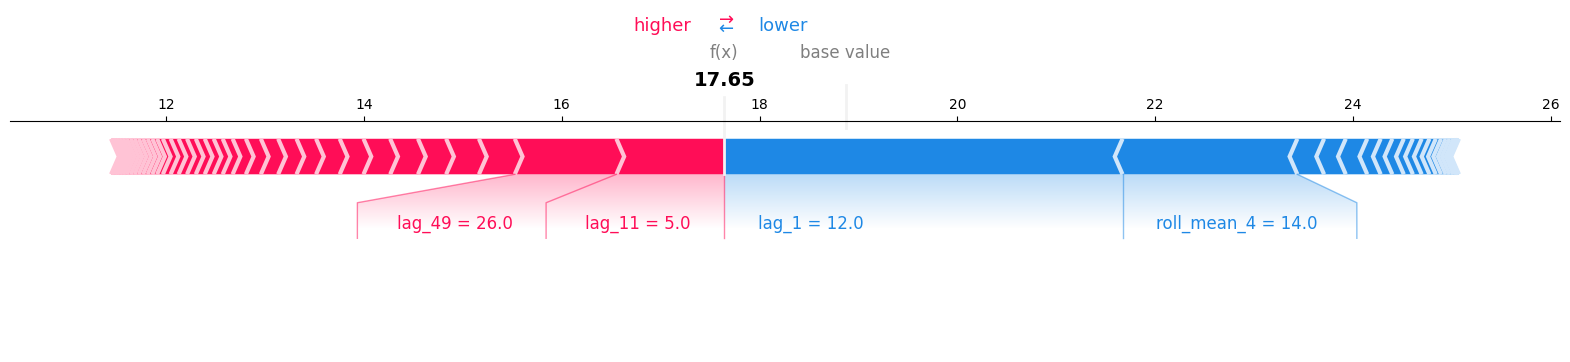

In [14]:
import shap
from sklearn.inspection import permutation_importance


# 1. XGBoost built-in feature importance (gain)
booster = xgb_model.get_booster()
gain_scores = booster.get_score(importance_type="gain")

fi = (
    pd.DataFrame({"feature": gain_scores.keys(), "gain": gain_scores.values()})
    .sort_values("gain")
)

plt.figure(figsize=(8, 6))
fi.plot.barh(x="feature", y="gain", legend=False)
plt.title("XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.show()

# 2. Permutation importance (test set)
perm = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=0,
    n_jobs=-1,
)

perm_df = (
    pd.DataFrame({"feature": X_test.columns,
                  "importance_mean": perm.importances_mean})
    .sort_values("importance_mean")
)

plt.figure(figsize=(8, 6))
perm_df.plot.barh(x="feature", y="importance_mean", legend=False)
plt.title("Permutation Importance (Test Set)")
plt.tight_layout()
plt.show()


# SHAP values (global explanations)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# SHAP summary (mean absolute contribution per feature)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Full SHAP beeswarm plot
shap.summary_plot(shap_values, X_test)


# # SHAP dependence plot for the top feature
# abs_importance = abs(shap_values).mean(axis=0)
# top_feature = X_test.columns[abs_importance.argmax()]

# print("Most influential SHAP feature:", top_feature)
# shap.dependence_plot(top_feature, shap_values, X_test)

# Local explanation for a single prediction
idx = 0  # sample index
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx],
    matplotlib=True,
)


# Future predictions and Explainability 

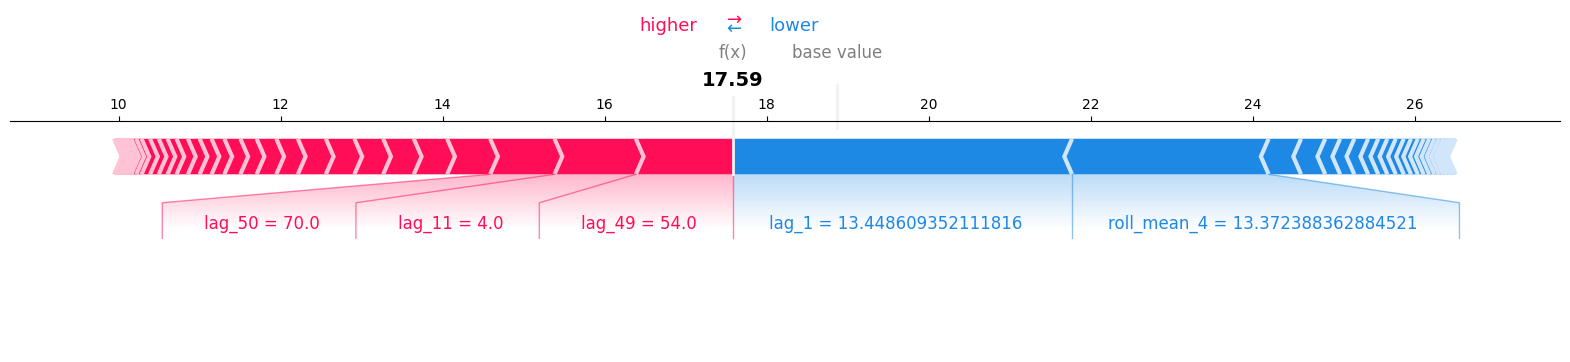

In [15]:
# Recursive multi-step forecasting 

future_weeks = [47, 48, 49, 50, 51, 52]
n_future = len(future_weeks)

# Start with the last 53 real values
hist = ts_data['confirmed_cases'].iloc[-53:].tolist()

future_preds = []
future_rows = []

for w in future_weeks:
    # Build dictionary for one future row
    row = {
        "epi_week": w,
    }

    # Add lag_1 ... lag_52 
    for i in range(1, 53):
        row[f"lag_{i}"] = hist[-i]

    # Add rolling means
    row["roll_mean_4"]  = np.mean(hist[-4:])
    row["roll_mean_12"] = np.mean(hist[-12:])
    row["roll_mean_52"] = np.mean(hist[-52:])

    # Convert to DataFrame with correct column order
    X_row = pd.DataFrame([row])[X_train.columns]

    # Predict 1 week ahead
    pred = xgb_model.predict(X_row)[0]

    # Store prediction and row
    future_preds.append(pred)
    future_rows.append(row)

    # Update history with prediction
    hist.append(pred)

# Build full future DF in the RIGHT order
X_future = pd.DataFrame(future_rows)[X_train.columns]

# SHAP values
future_shap = explainer.shap_values(X_future)



# Local explanation for first future week

i = 3  # corresponds to epi_week 47
shap.force_plot(
    explainer.expected_value,
    future_shap[i],
    X_future.iloc[i],
    matplotlib=True,
)

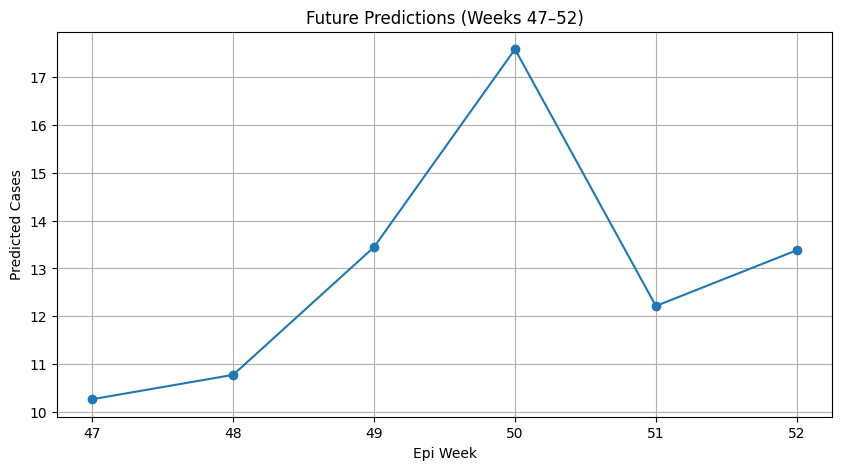

In [16]:
# Plot future predictions 
plt.figure(figsize=(10,5))
plt.plot(future_weeks, future_preds, marker="o", label="Forecast")
plt.title("Future Predictions (Weeks 47–52)")
plt.xlabel("Epi Week")
plt.ylabel("Predicted Cases")
plt.grid(True)
plt.show()


# Summary 

In this notebook, I implemented an XGBoost model on the Lassa fever dataset. Because tree-based models cannot directly interpret time, I first had to engineer features that capture temporal structure. This meant creating lag features so the model could learn from past values.

I began with just four time lags. After training the model and evaluating performance, the results were already slightly better than the previous best traditional model (SARIMA), although the improvements in MAE, RMSE, and MAPE were marginal.

Next, I expanded the feature set to include 52 time lags, representing a full year’s history. This produced a significant improvement in performance over both the earlier XGBoost model and the classical models.

Finally, I added rolling averages over 4, 12, and 52 weeks (representing short-term, medium-term, and annual trends). With these rolling features included, performance improved dramatically. Compared to SARIMA, MAE dropped from 7.64 → 5.90, RMSE from 12.45 → 8.36, and MAPE from 44.46 → 33.28. These results also represent more than a 100% improvement over some of the baseline models.

Feature importance analyses (gain, permutation importance, and SHAP) all pointed to the same structure: the 4-week rolling mean dominated, indicating that short-term momentum is the strongest predictor of next-week incidence. lag_1 was the next most influential, followed by seasonal lags (49–52), and the epidemic-week variable, which captures the known dry-season peak.

These results align with established Lassa fever epidemiology: recent transmission intensity, seasonal memory, and position within the year are key drivers.

Next, I plan to incorporate rainfall and humidity data. Because environmental conditions may influence transmission with delayed effects, I will explore how lagged climate variables interact with temporal structure and how they affect model performance and feature importance.

Performance Table

| Model                       | MAE      | RMSE     | MAPE      |
| --------------------------- | -------- | -------- | --------- |
| Naive                       | 16.33    | 26.37    | 60.30     |
| Average                     | 16.20    | 20.94    | 129.03    |
| Drift                       | 17.69    | 27.12    | 69.84     |
| Seasonal Naive              | 8.74     | 15.53    | 49.24     |
| Seasonal Mean               | 7.91     | 12.25    | 44.11     |
| ETS                         | 8.06     | 12.79    | 43.90     |
| SARIMA                      | 7.64     | 12.45    | 44.46     |
| **XGB (52 lags + rolling)** | **5.90** | **8.36** | **33.28** |


XGBoost Experiments
| Feature Set                      | MAE      | RMSE     | MAPE      |
| -------------------------------- | -------- | -------- | --------- |
| 4 time lags                      | 7.68     | 11.94    | 42.76     |
| 52 time lags                     | 7.11     | 10.69    | 42.66     |
| **52 time lags + rolling means** | **5.90** | **8.36** | **33.28** |
